NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

LAB SHEET - 06

In [1]:
import os

print("Files available in /content:")
for file in os.listdir('/content'):
    print(file)

Files available in /content:
.config
.ipynb_checkpoints
my_image.jpg
drive
sample_data


In [2]:
IMAGE_PATH = "/content/my_image.jpg"

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
IMAGE_PATH = "/content/my_image.jpg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully.")
    print("Image shape:", image.shape)

Image loaded successfully.
Image shape: (2519, 3872, 3)


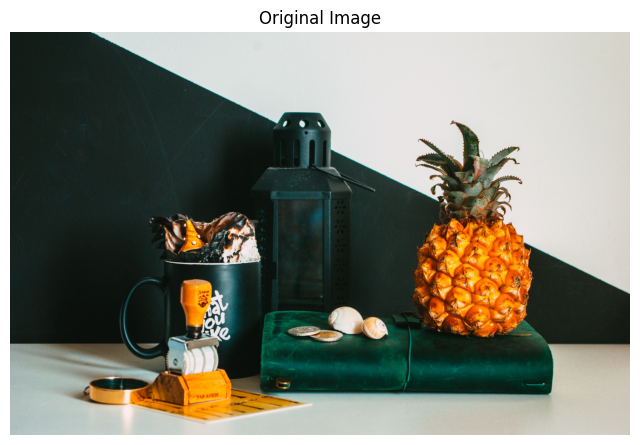

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

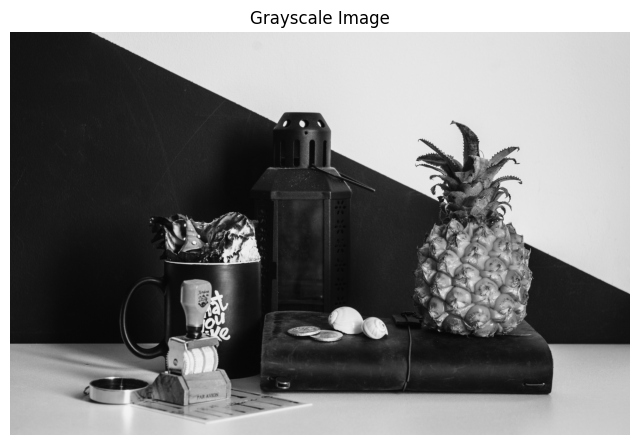

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

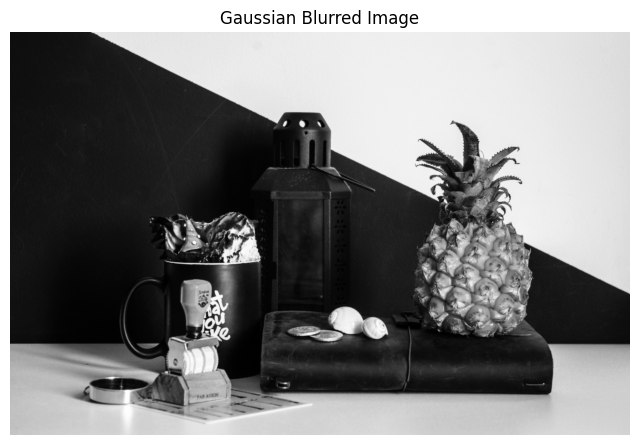

In [7]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

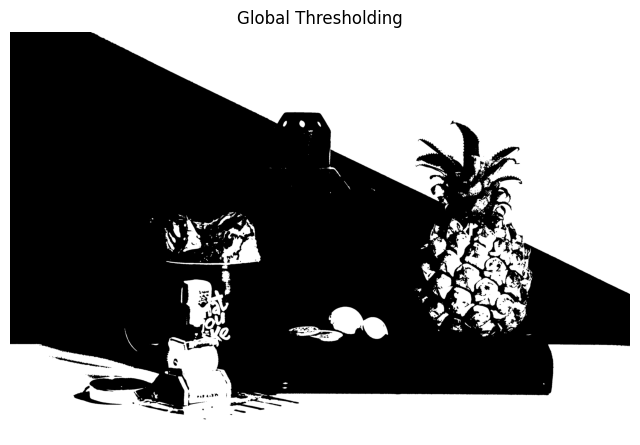

In [8]:
threshold_value = 127

_, global_threshold = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(8, 6))
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

Otsu's threshold value: 121.0


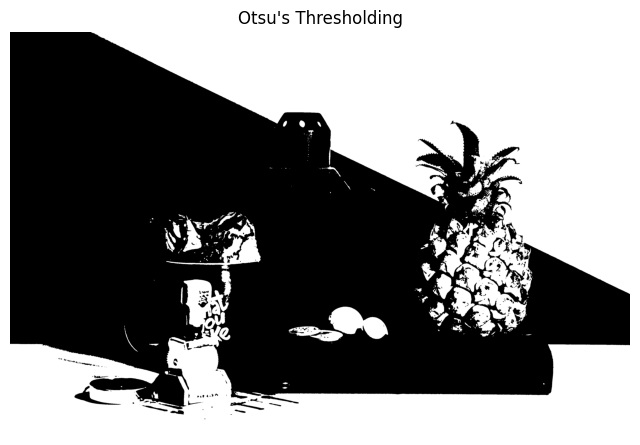

In [9]:
otsu_value, otsu_threshold = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu's threshold value:", otsu_value)

plt.figure(figsize=(8, 6))
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")
plt.show()

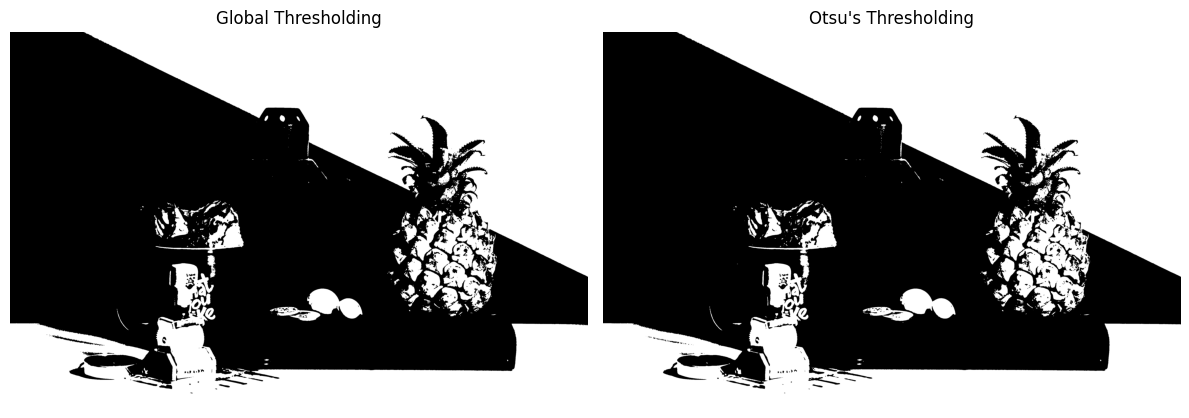

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()

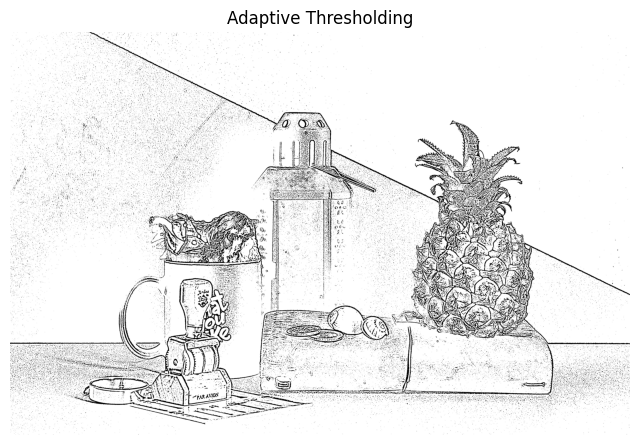

In [11]:
adaptive_threshold = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(8, 6))
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

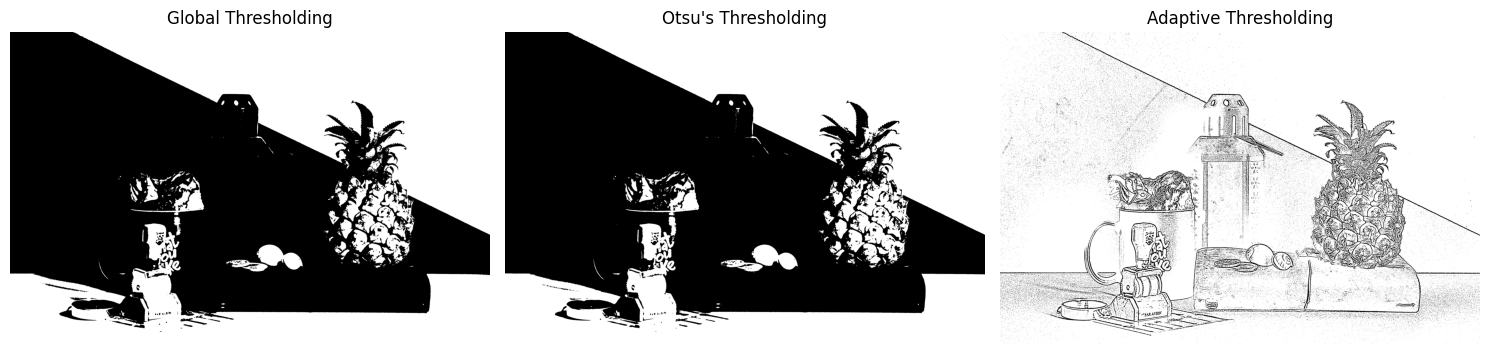

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()

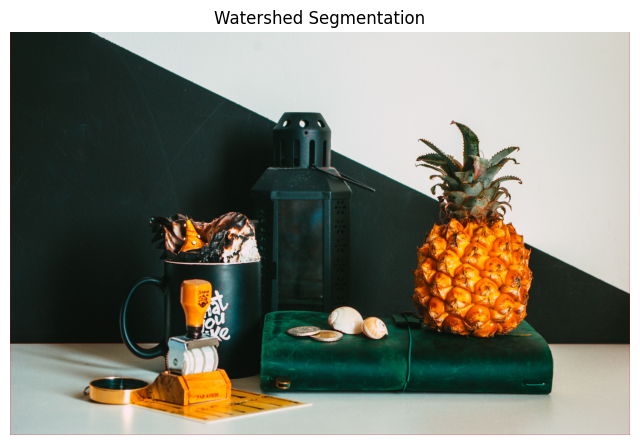

In [13]:
# Create a binary image
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove small noise
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Marker labelling
num_markers, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

# Convert original image for watershed
watershed_image = image.copy()

# Apply Watershed
markers = cv2.watershed(
    watershed_image,
    markers
)

# Mark watershed boundaries in red
watershed_result = image_rgb.copy()
watershed_result[markers == -1] = [255, 0, 0]

plt.figure(figsize=(8, 6))
plt.imshow(watershed_result)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

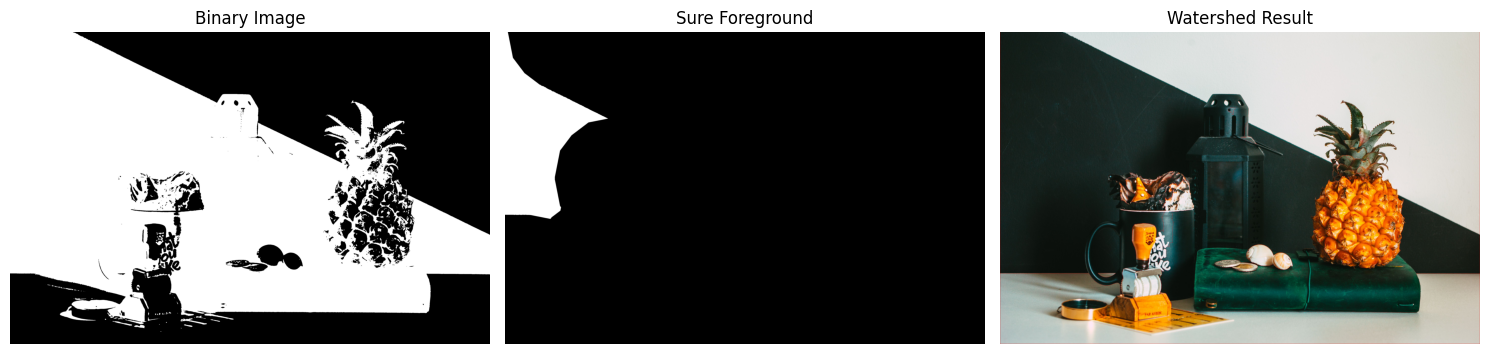

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sure_fg, cmap="gray")
plt.title("Sure Foreground")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(watershed_result)
plt.title("Watershed Result")
plt.axis("off")

plt.tight_layout()
plt.show()

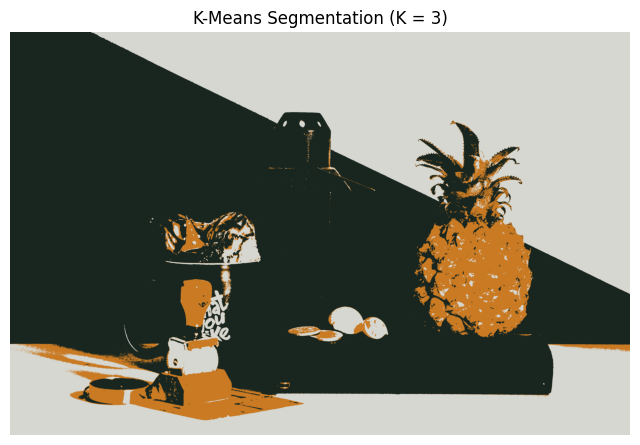

In [15]:
# Convert image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape image into a list of pixels
pixel_data = image_rgb.reshape((-1, 3))

# Convert to float32
pixel_data = np.float32(pixel_data)

# Number of clusters
k = 3

# Define stopping criteria
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

# Apply K-Means
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixel_data)

# Get cluster centers
centers = np.uint8(kmeans.cluster_centers_)

# Replace every pixel with its cluster center
segmented_pixels = centers[labels]

# Reshape back into image
segmented_image = segmented_pixels.reshape(image_rgb.shape)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_image)
plt.title("K-Means Segmentation (K = 3)")
plt.axis("off")
plt.show()

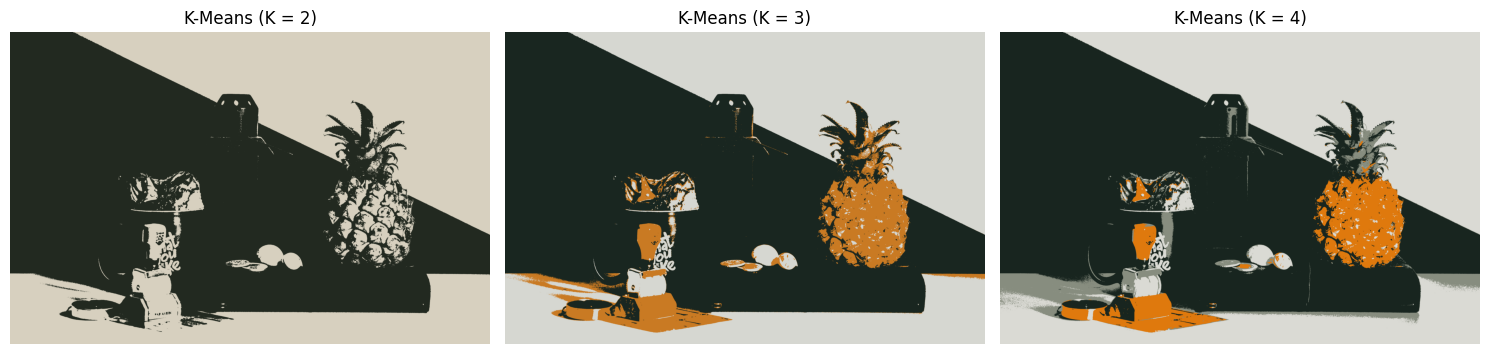

In [16]:
cluster_values = [2, 3, 4]

plt.figure(figsize=(15, 5))

for i, k in enumerate(cluster_values):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(pixel_data)
    centers = np.uint8(kmeans.cluster_centers_)

    segmented_pixels = centers[labels]
    segmented_image = segmented_pixels.reshape(image_rgb.shape)

    plt.subplot(1, 3, i + 1)
    plt.imshow(segmented_image)
    plt.title(f"K-Means (K = {k})")
    plt.axis("off")

plt.tight_layout()
plt.show()

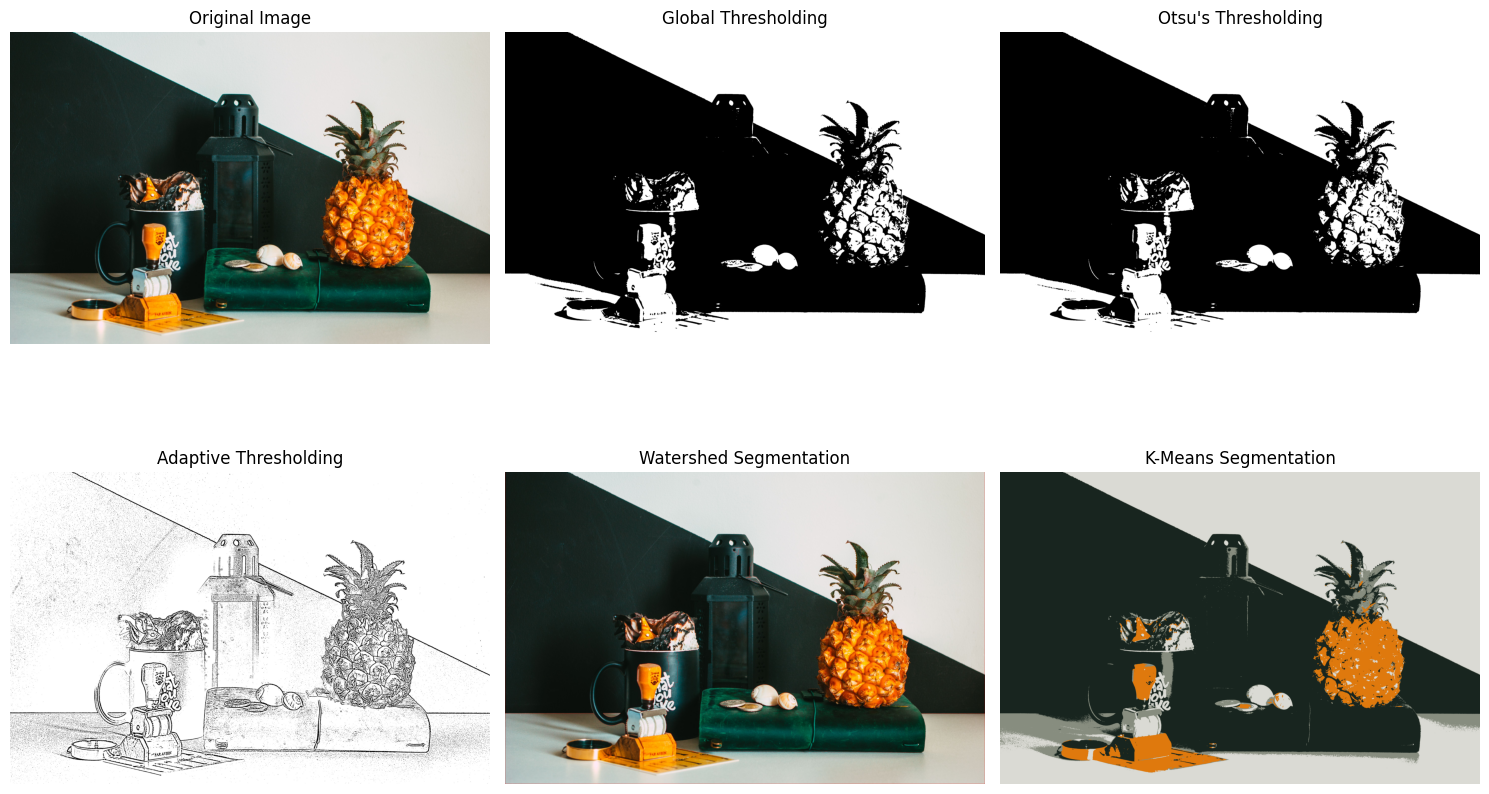

In [17]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_result)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

## Experiment No. 6 — Theory Questions and Answers

### Ques 1- What is image segmentation? Why is it considered a fundamental step in computer vision?

**Ans-** Image segmentation is the process of dividing a digital image into multiple meaningful regions or objects based on characteristics such as pixel intensity, color, texture, or boundaries. It helps isolate the regions of interest (ROI) from the rest of the image.

It is considered a fundamental step in computer vision because it simplifies image analysis by separating relevant objects or regions. This makes subsequent tasks such as object detection, medical diagnosis, autonomous navigation, and industrial inspection more accurate and efficient.

---

### Ques 2- Differentiate between Image Segmentation and Image Classification.

**Ans-** Image segmentation and image classification are both important computer vision tasks, but they serve different purposes.

Image segmentation divides an image into meaningful regions or objects and determines the location of different parts of the image at the pixel or region level.

Image classification assigns a label or category to an entire image based on its overall content. For example, a classification system may identify an image as a cat or dog, whereas a segmentation system identifies the exact pixels belonging to the cat or dog.

Therefore, segmentation focuses on **where an object is located**, while classification focuses on **what the image or object represents**.

---

### Ques 3- Explain the working principle of Global Thresholding, Otsu's Thresholding, and Adaptive Thresholding.

**Ans-**

**Global Thresholding:**
Global thresholding uses a single threshold value for the entire image. Pixels above the selected threshold are assigned to one region, while pixels below it are assigned to another region. It works well when the foreground and background have clearly different intensity levels.

**Otsu's Thresholding:**
Otsu's thresholding automatically determines an optimal threshold value from the image histogram. It selects the threshold that provides the best separation between different intensity classes, reducing the need to manually choose a threshold.

**Adaptive Thresholding:**
Adaptive thresholding calculates different threshold values for different local regions of an image rather than using one threshold for the entire image. Therefore, it is particularly useful when the image has uneven illumination or varying brightness levels. The experiment specifically uses adaptive thresholding for such conditions.

---

### Ques 4- What is the Watershed Algorithm? Why is it useful for separating overlapping objects?

**Ans-** The Watershed Algorithm is an image segmentation technique that treats an image as a topographic surface and identifies boundaries between different regions. It is useful for separating objects that are touching or overlapping.

In the experiment, Watershed Segmentation is applied specifically to separate overlapping or connected objects. By identifying appropriate foreground and background regions and determining the boundaries between them, the algorithm can distinguish individual objects that may otherwise appear as a single connected region.

---

### Ques 5- How is K-Means Clustering applied to image segmentation?

**Ans-** K-Means Clustering is applied to image segmentation by treating image pixels as data points and grouping them into a predefined number of clusters based on their similarity.

For color-based segmentation, the color values of pixels are used as features. K-Means assigns pixels to the nearest cluster center and repeatedly updates the cluster centers until the groups become stable. Each cluster represents a different region of the image.

Thus, pixels with similar colors are grouped together, producing a segmented image with distinct regions. The experiment uses K-Means for color-based image segmentation.

---

### Ques 6- Compare threshold-based segmentation and clustering-based segmentation techniques.

**Ans-** Threshold-based and clustering-based segmentation differ mainly in how they divide an image.

**Threshold-based segmentation** separates pixels using threshold values. Global, Otsu's, and Adaptive Thresholding belong to this category. These methods are generally simple and computationally efficient, but their effectiveness can depend on image intensity distribution and illumination conditions.

**Clustering-based segmentation** groups pixels according to their similarity in features such as color or intensity. K-Means is an example of a clustering-based technique. It can handle multiple regions and colors more flexibly, but it may require more computation and the number of clusters must usually be specified.

Therefore, thresholding is generally simpler and faster, whereas clustering provides more flexible segmentation for images containing multiple regions or colors.

---

### Ques 7- What challenges are encountered while segmenting images with complex backgrounds or varying illumination?

**Ans-** Images with complex backgrounds or varying illumination are difficult to segment because the foreground and background may have similar intensity or color values. Shadows, reflections, noise, low contrast, and changes in brightness can also make object boundaries difficult to identify.

A single global threshold may fail when different parts of an image have different illumination levels. In such cases, techniques such as Adaptive Thresholding or more advanced segmentation methods may provide better results.

---

### Ques 8- Mention five real-world applications where image segmentation plays a critical role.

**Ans-** Five important real-world applications of image segmentation are:

1. **Medical diagnosis** — isolating organs, tissues, or abnormal regions in medical images.
2. **Object detection and recognition** — separating objects from their backgrounds.
3. **Autonomous navigation** — identifying roads, obstacles, and surrounding regions.
4. **Industrial inspection** — detecting defects and identifying regions of interest in manufactured products.
5. **Scene understanding** — dividing an image into meaningful regions to understand its contents.

These applications depend on segmentation to isolate relevant regions and simplify further computer vision analysis.

---

### Ques 9- How does image segmentation improve the performance of object detection and image recognition systems?

**Ans-** Image segmentation improves object detection and image recognition by separating important objects or regions from irrelevant background information. This reduces the amount of unnecessary information that the system has to process.

By isolating the region of interest, segmentation can make object boundaries clearer and provide more focused input for later computer vision tasks. As a result, object detection and recognition systems can become more accurate and efficient. The lab sheet identifies object localization and subsequent computer vision tasks as key purposes of segmentation.

---

### Ques 10- Compare traditional image segmentation techniques with deep learning-based segmentation methods such as U-Net and Mask R-CNN.

**Ans-** Traditional image segmentation techniques include methods such as thresholding, Otsu's thresholding, adaptive thresholding, watershed segmentation, and K-Means clustering. These methods are generally based on manually designed rules, pixel intensity, color, boundaries, or clustering. They are relatively simple and can work well for images with clear characteristics.

Deep learning-based methods such as **U-Net** and **Mask R-CNN** learn segmentation patterns automatically from training data. They can handle complex images and learn detailed features, making them more suitable for difficult segmentation tasks. However, they generally require substantial labeled training data and greater computational resources.

Therefore, traditional techniques are simpler and often suitable for straightforward problems, while deep learning-based techniques are generally more powerful for complex real-world segmentation problems.

